# LAB09

#### TRAVELLING SALESMAN PROBLEM E ALGORITMI GENETICI
In questo esercizio viene richiesta la risoluzione del *Travelling Salesman Problem*. Dato un insieme di città e le rispettive distanze reciproche, il problema consiste nel determinare il percorso chiuso di lunghezza minima che visiti ogni città una sola volta e che ritorni alla città iniziale. Dunque, il problema consiste nella ricerca della permutazione ottimale delle città che minimizza la lunghezza totale del cammino. Tuttavia, nel caso di $N$ città il numero di possibili percorsi cresce fattorialmente rendendo impossibile una ricerca esaustiva già per valori moderati di $N$: per questo motivo, si ricorre all'utilizzo di un algoritmo genetico. 

In generale, gli algoritmi genetici sono algoritmi di ottimizzazione ispirati ai meccanismi dell'evoluzione biologica e della selezione naturale. L’idea fondamentale consiste nel far evolvere una popolazione di possibili soluzioni del problema attraverso un insieme di operazioni genetiche analoghe a quelle presenti nei sistemi biologici, ovvero selezione naturale, crossover e mutazione. Ogni possibile soluzione del problema viene rappresentata come un individuo della popolazione: nel caso del Travelling Salesman Problem, ogni individuo rappresenta un possibile percorso che attraversa tutte le città. La qualità di una soluzione viene valutata mediante una funzione di fitness, che in questo caso coincide con la lunghezza del percorso:

$$ L = \sum_{i=1}^N |\vec{x}_{i+1} - \vec{x}_i| $$

L’obiettivo dell’algoritmo consiste quindi nel minimizzare tale quantità.


#### STRUTTURA DEL CODICE
L’implementazione è stata organizzata secondo una struttura modulare basata su classi C++. Di seguito sono descritte le varie classi con i propri metodi principali. 

**Classe City**

La classe `City` rappresenta una singola città del problema TSP che è identificata mediante le proprie coordinate cartesiane nel piano.

**Classe Individual**

La classe `Individual` rappresenta un possibile percorso del TSP. Ogni individuo è descritto da una permutazione delle città, dove il primo elemento della permutazione viene mantenuto fisso per eliminare le simmetrie traslazionali del problema.

Tra i principali metodi di `Individual` troviamo `ComputeFitness`: questa funzione calcola la lunghezza totale del percorso associato all’individuo. Inoltre, sono presenti gli operatori di mutazione, che mantengono la diversità genetica della popolazione: 
- `SwapMutation`: scambia la posizione tra due città casuali.
- `ShiftMutation`: effettua una traslazione ciclica di un blocco di città.
- `BlockMutation`: scambia due blocchi di città.
- `InversionMutation`: inverte l’ordine delle città all’interno di un segmento del percorso.

Infine, un altro metodo importante è `Check`: si tratta di una funzione di controllo per verificare che ogni città compaia una sola volta, nessuna città venga dimenticata e il primo elemento resti fisso. 

**Classe Population**

La classe `Population` contiene l’insieme degli individui della popolazione: come membro ha infatti un vettore di individui. 

Questa classe si occupa dell'ordinamento degli individui della popolazione tramite il metodo `Sort`: in particolare, gli individui vengono ordinati in base alla fitness crescente, permettendo così di identificare le configurazioni ottimali. 

Un altro metodo fondamentale di questa classe è `Selection`, che si occupa della selezione degli individui. La selezione degli individui viene effettuata in modo probabilistico, privilegiando gli individui con fitness migliore. Dopo aver ordinato la popolazione per fitness crescente, viene selezionato l’individuo di indice: 
$$j=[M r^p]$$
dove $[\,]$ indica la parte intera, $M$ è la dimensione della popolazione, $r \in [0,1)$ è un numero casuale uniforme e $p=2$ controlla la pressione selettiva. In questo modo gli individui migliori vengono scelti più frequentemente, pur mantenendo una certa diversità genetica nella popolazione.

**Classe GeneticAlgorithm**

La classe `GeneticAlgorithm` coordina l’intero processo evolutivo, gestendo il crossover, le mutazioni e l'evoluzione delle generazioni. 

Nel caso del TSP non è possibile utilizzare un crossover standard, poiché ciò produrrebbe percorsi con città duplicate o mancanti. È stato quindi implementato un `Crossover` compatibile con permutazioni che opera nel seguente modo: 
1. Viene scelto casualmente un punto di taglio
2. La prima parte del percorso viene copiata direttamente dal rispettivo genitore
3. La seconda parte viene completata utilizzando l’ordine delle città presenti nell’altro genitore, evitando però duplicazioni.
In questo modo l’operatore di crossover implementato produce simultaneamente due nuovi individui figli a partire da una coppia di genitori.

Il metodo `Evolve` è il centro di tutto l'algotmo e gestisce la transizione da una generazione alla successiva della popolazione. L’obiettivo di questa funzione è costruire una nuova popolazione a partire da quella attuale, applicando iterativamente: 
1. Selezione dei genitori: ad ogni iterazione vengono selezionati due individui dalla popolazione corrente; come già discusso, la selezione non è uniforme, ma biasata verso individui con fitness migliore, così da favorire la sopravvivenza dei percorsi più efficienti.
2. Crossover: viene applicato con una certa probabilità $r < p_{cross}$, dove $r$ è un numero casuale e $p_{cross}=0.8$ è un parametro fissato.  
3. Mutazione: su entrambi i figli vengono applicate delle mutazioni (swap, shift, block e inversion), che introducono variazioni casuali nel percorso.
4. Calcolo della fitness
5. Sostituzione della popolazione








#### RISULTATI OTTENUTI
Sono state considerate due differenti distribuzioni geometriche delle città:
- città distribuite su una circonferenza di raggio unitario
- città distribuite casualmente all’interno di un quadrato unitario

Per monitorare le prestazioni dell’algoritmo sono state analizzate due quantità, ovvero la fitness del miglior individuo e la fitness media della migliore metà della popolazione. La quantità media è definita come: 

$$ \braket{L}_{\text{best half}} = \frac{2}{M} \sum_{i=0}^{M/2 -1} L_i$$

dove la popolazione è ordinata per fitness crescente. I grafici mostrano una progressiva diminuzione della lunghezza media del percorso, indicando una corretta convergenza dell’algoritmo. I grafici mostrati di seguito sono stati ottenuti utilizzando delle popolazioni di 200 individui per un totale di 600 generazioni. 

Inoltre, per entrambe le distribuzioni di città, viene mostrato il miglior percorso ottenuto. Nel caso delle città distribuite sulla circonferenza, l’algoritmo tende naturalmente a ricostruire il bordo circolare: il miglior percorso equivale infatti a poco meno di $2\pi$. Nel caso del quadrato, invece, il percorso presenta una struttura più irregolare ma comunque ottimizzata.

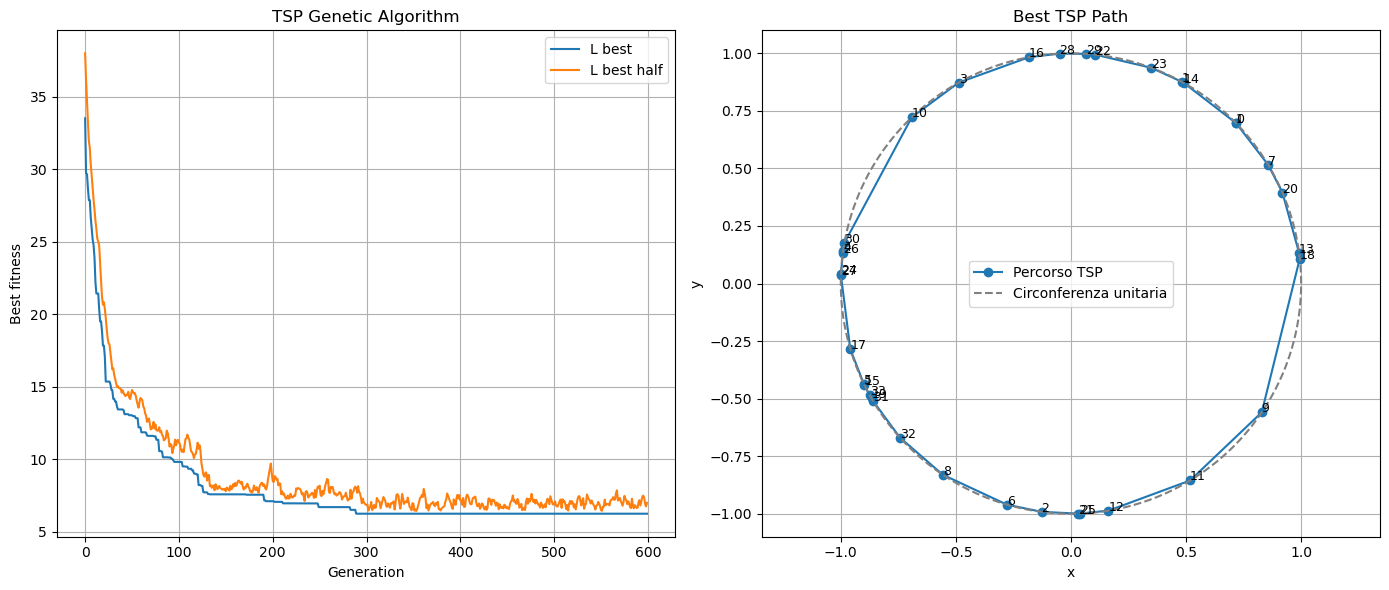

Lunghezza miglior percorso: 6.24306


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# LETTURA DATI
fitness_data = np.loadtxt("Output/best_loss_c.dat")
generation = fitness_data[:,0]
fitness    = fitness_data[:,1]

ave_data = np.loadtxt("Output/ave_c.dat")
generation = ave_data[:,0]
ave    = ave_data[:,1]

path_data = np.loadtxt("Output/best_path_c.dat")
city_id = path_data[:,0]
x = path_data[:,1]
y = path_data[:,2]


fig, ax = plt.subplots(1, 2, figsize=(14,6))



# PLOT FITNESS VS GENERAZIONE
ax[0].plot(generation, fitness, label = "L best")
ax[0].plot(generation, ave, label = "L best half")
ax[0].set_xlabel("Generation")
ax[0].set_ylabel("Best fitness")
ax[0].set_title("TSP Genetic Algorithm")

ax[0].grid(True)
ax[0].legend()



# PLOT BEST PATH
theta = np.linspace(0, 2*np.pi, 200)
circle_x = np.cos(theta)
circle_y = np.sin(theta)



ax[1].plot(x, y, marker='o', label="Percorso TSP")

for i in range(len(city_id)):
    ax[1].text(x[i], y[i], str(int(city_id[i])), fontsize=9)

ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].set_title("Best TSP Path")
ax[1].plot(circle_x, circle_y, linestyle='--', color='grey', label="Circonferenza unitaria")
ax[1].axis('equal')
ax[1].grid(True)
ax[1].legend()


plt.tight_layout()
plt.show()

best_path_length = fitness[-1]
print(f"Lunghezza miglior percorso: {best_path_length}")

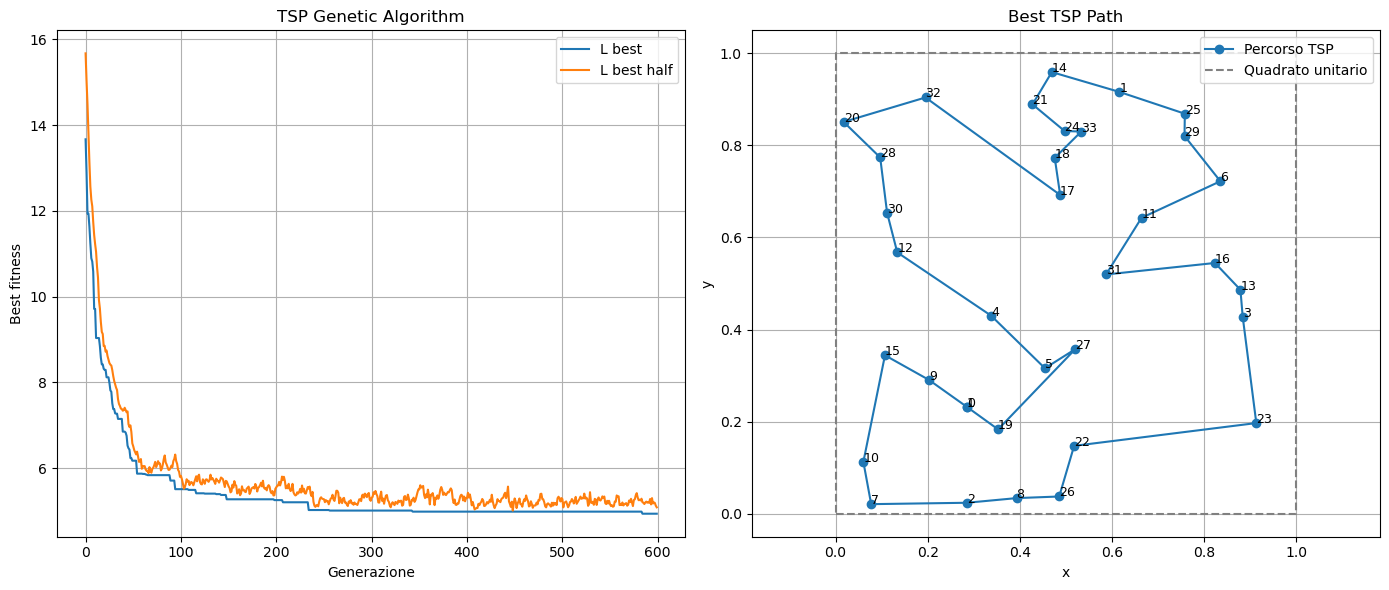

Lunghezza miglior percorso: 4.93439


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# LETTURA DATI
fitness_data = np.loadtxt("Output/best_loss.dat")
generation = fitness_data[:,0]
fitness    = fitness_data[:,1]

path_data = np.loadtxt("Output/best_path.dat")
city_id = path_data[:,0]
x = path_data[:,1]
y = path_data[:,2]

ave_data = np.loadtxt("Output/ave.dat")
generation = ave_data[:,0]
ave    = ave_data[:,1]


fig, ax = plt.subplots(1, 2, figsize=(14,6))



# PLOT FITNESS VS GENERAZIONE
ax[0].plot(generation, fitness, label = "L best")
ax[0].plot(generation, ave, label = "L best half")
ax[0].set_xlabel("Generazione")
ax[0].set_ylabel("Best fitness")
ax[0].set_title("TSP Genetic Algorithm")
ax[0].grid(True)
ax[0].legend()


# PLOT BEST PATH
square_x = [0, 1, 1, 0, 0]
square_y = [0, 0, 1, 1, 0]

ax[1].plot(x, y, marker='o', label = "Percorso TSP")

for i in range(len(city_id)):
    ax[1].text(x[i], y[i], str(int(city_id[i])), fontsize=9)

ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].set_title("Best TSP Path")
ax[1].plot(square_x, square_y, linestyle='--', color= 'gray', label = "Quadrato unitario")
ax[1].axis('equal')

ax[1].grid(True)
ax[1].legend()



plt.tight_layout()
plt.show()

best_path_length = fitness[-1]
print(f"Lunghezza miglior percorso: {best_path_length}")

## COSA HO FATTO
### idea generale
Ho pensato di fare diverse classi: 
- City: contiene le coordinate della città
- individuo: possibile percorso del commesso viaggiatore
- popolazione: insieme di percorsi
- fitness: lunghezza del percorso
Ad ogni generazione: seleziono i genitori, faccio crossover, faccio mutazioni -> creo nuova popolazione -> tengo i migliori.

Per rappresentare il percorso è un vettore di interi 1D

l'algoritmo ad ogni generazione fa così: 
1. ordina popolazione
2. salva statistiche
3. crea nuova popolazione
4. seleziona genitori
5. crossover
6. mutazioni
7. check validità
8. sostituisci vecchia popolazione

### INDIVIDUAL
cosa deve fare Individual: 
- check validità: verificare che la prima città è fissata e che le città sono presenti una sola volta
- calcolo lunghezza del percorso
- Mutazioni:
    - swap: scambio di due città
    - shift
    - block permutation
    - invertion 

### POPULATION
cosa deve fare:
- costruttore: genera individui casuali
- compute fitnesses: calcola il tragitto di ogni individuo
- ordinamento (sort): ordina per fitness (quindi il migliore sarà individuals[0])
- selezione: non scegliamo il migliore in asso. vogliamo infatti favorire gli individui migliori ma allo stesso tempo mantenere la diversità genetica: quindi i i migliori vengono scelti MOLTO spesso, i peggiori ogni tanto. Per fare questo selezioniamo l'indice j che è la parte intera di $M \cdot r^p$, dove $M$ è la dimensione della popolazione, $r$ è un numero compreso tra 0 e 1 e $p=2$ (in modo da favorire gli indici bassi. Ricordo che i primi elementi di individuals sono quelli migliori perchè hanno un percorso breve 


- media miglior metà (?)
  
### GENETIC ALGORITHM 
deve coordinare il tutto. 

- crossover: vedi nb prof
- mutate: il GeneticAlgotithm ha una certa p_mut. vengono estratti dei numeri casuali: se sono minuri di questa probabilità allora avvengono le mutazioni che sono presenti nella classe individual
- evolve:

### MAIN:
- inizializzazione generatore numeri casuali
- creazione del vettore di città e riempimento con città nel quadrato
- creazione di GA e loop evolutivo -> viene stampato il fitness del miglior individuo (su file_loss) e viene controllato che superi il check (stampo su file check una serie di 0 o 1: se sono tutti 1 ok)
- stampa del miglior path (la prima città viene ripetuta alla fine per chiudere il percorso)



